## Extended Thinking
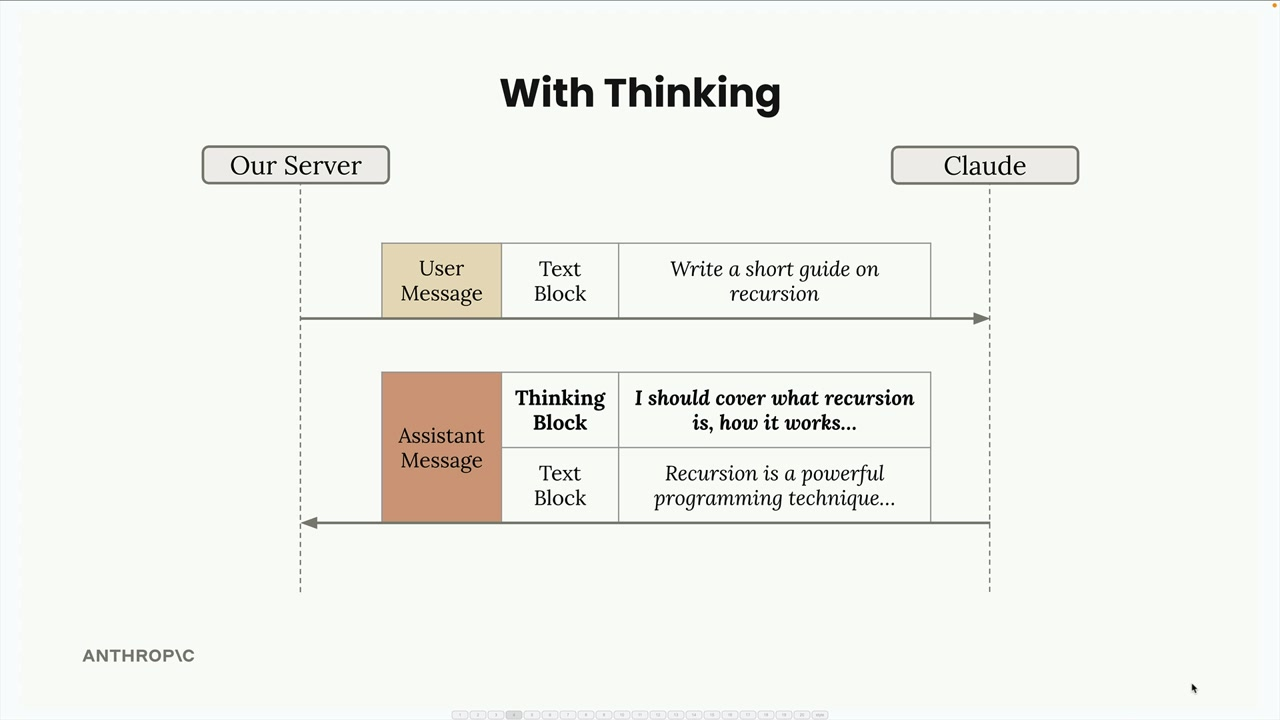
With thinking enabled, you get both the reasoning process and the final answer:
To enable extended thinking in your code, you need to add two parameters to your chat function:
```
def chat(
    messages,
    system=None,
    temperature=1.0,
    stop_sequences=[],
    tools=None,
    thinking=False,
    thinking_budget=1024
):
```
The thinking budget sets the maximum tokens Claude can use for reasoning. The minimum value is 1024 tokens, and your max_tokens parameter must be greater than your thinking budget.

Add the thinking configuration to your API parameters
```

```

In [ ]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-sonnet-4-5"

In [ ]:
# Helper functions
from anthropic.types import Message

# Magic string to trigger redacted thinking
thinking_test_str = "ANTHROPIC_MAGIC_STRING_TRIGGER_REDACTED_THINKING_46C9A13E193C177646C7398A98432ECCCE4C1253D5E2D82641AC0E52CC2876CB"


def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(assistant_message)


def chat(
    messages,
    system=None,
    temperature=1.0,
    stop_sequences=[],
    tools=None,
    thinking=False,
    thinking_budget=1024,
):
    params = {
        "model": model,
        "max_tokens": 4000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if thinking:
        params["thinking"] = {
            "type": "enabled",
            "budget_tokens": thinking_budget,
        }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message


def text_from_message(message):
    return "\n".join([block.text for block in message.content if block.type == "text"])

In [ ]:
messages = []

add_user_message(messages, thinking_test_str)

chat(messages, thinking=True)

Message(id='msg_0183vZe2HBzE62vptCvwV7sZ', content=[RedactedThinkingBlock(data='EtcGCkYIAxgCKkA5ARFLpCpwMLfr/Yay7pBreer2GmgGShPJOy+XL0GXbOIadqOPUSauVM++DQfK8wqs3t1zTG10GDBFeOiC7OcUEgx5Aqyir9dh1FHGsrQaDICozuiFF40ZkXmIHCIwbz+GLy+Sk5503ESJLS2SCf/MKJ1CrdeF7oti1Khm78tqRvCZD/PP2BB9694uE5PCKr4FDBMr92mHP8jTJe1kb8kFa8Zi14FQGT+2FvN+IyObltyhkvC0NSPhO4Su8LpikN+JdjSsCqEKpqLYS4bPCQQNVpp8cNvPRmmvVpE5sbdF+C1l1hX5L2j95f8PbpBqOSfcIpDOoQ7o6MgxTpHezvXsTZaaXocxz0jea5jaXcCdqBnXnSRJQnxL3EuTnWulniO2+lUBIrek3q493GaX/SQ/2JCHmv/QIYN4wq/R9DXkK+pakUvil3bNB+Sgy5IjR7o/q5XMtmHlgDGuP1l8AxAbyfJJwQIGteBXHfTFFa4Ah+JMk2EIzjGZ6CqCgr5EnoUFkonWVFOBWVyQdM1e8tr3GTNguVX1BlRKmxzQU9/vJZ/CoYSoo8n6GgvCDWWoCTwozWjgjAMtUoltdq2OOq22i+rSHtUBWR/hnQuIsd/BNIFletVW8rgFSyFKJUwPs0CBlr4i31gt7LF6nSvPt+MbB9eZNomBPPO4s7hsdJ5gH2X6SLAleFmccUfiwS8sXp/9QKQvLccOi8xn1gZwADI4uZTihTPWKxv7RzdMYu3uyFwmZb9JZXb4a1H9PSgc7afQWvX2s+A+mUVA1lP4iu0XzGGfekvmP4/MEXKbkY38iqwuuaqnG+UrqCfDWBBzEb/seoDI3W3NnmJLNRMXZlcBjQAYp9F7x9NVt/YVtD9ELtNiaOT6keQeAEcnbGGGwHNZ5Dqdhhnt